# Overview

Simple demo with flu model with "toy" (not necessarily realistic or finalized) parameters

We go over
- How to set up subpopulation models and metapopulation models.
- How to run accept-reject algorithm.
- How to run experiments to organize output of multiple replications. 

# Imports

In [1]:
# Misc: suppress SSE4.2 deprecation warnings
# This is not an error, just a warning about future hardware compatibility (not relevant in general)
import os
os.environ["MKL_DEBUG_CPU_TYPE"] = "5" 

from pathlib import Path
import numpy as np
import pandas as pd

# Import city-level transmission base components module
import clt_toolkit as clt

# Import flu model module, which contains customized subclasses
import flu_core as flu

# Import immunity module, which contains some nice graphing functions
#import toy_immunity_core as imm

import json

# Reading Input Files

In [2]:
# Note that this can be cumbersome due to the complexity of the model 
# Users may prefer to create the model inputs or even the models themselves in a separate .py file and import them! 

# Obtain path to folder with JSON input files
#base_path = clt.utils.PROJECT_ROOT / "flu_instances" / "austin3_input_files_2023_2024"
base_path = clt.utils.PROJECT_ROOT / "flu_instances" / "austin3_input_files_2024_2025"

# Get filepaths for east subpopulation
east_compartments_epi_metrics_init_vals_filepath = base_path / "init_vals_East.json"

# Read in files as dictionaries and dataframes for east subpopulation
# Note that we can also create these dictionaries directly
#   rather than reading from a predefined input data file.
east_state = clt.make_dataclass_from_json(east_compartments_epi_metrics_init_vals_filepath,
                                     flu.FluSubpopState)
east_vaccines_df = pd.read_csv(base_path / "daily_vaccines_East.csv", index_col=0)
east_calendar_df = pd.read_csv(base_path / "school_work_calendar_austin_East.csv", index_col=0)

# Get filepaths for mid subpopulation
mid_compartments_epi_metrics_init_vals_filepath = base_path / "init_vals_Mid.json"

# Read in files as dictionaries and dataframes for east subpopulation
# Note that we can also create these dictionaries directly
#   rather than reading from a predefined input data file.
mid_state = clt.make_dataclass_from_json(mid_compartments_epi_metrics_init_vals_filepath,
                                     flu.FluSubpopState)
mid_vaccines_df = pd.read_csv(base_path / "daily_vaccines_Mid.csv", index_col=0)
mid_calendar_df = pd.read_csv(base_path / "school_work_calendar_austin_Mid.csv", index_col=0)

# Get filepaths for west subpopulation
west_compartments_epi_metrics_init_vals_filepath = base_path / "init_vals_West.json"

# Read in files as dictionaries and dataframes for west subpopulation
# Note that we can also create these dictionaries directly
#   rather than reading from a predefined input data file.
west_state = clt.make_dataclass_from_json(west_compartments_epi_metrics_init_vals_filepath,
                                     flu.FluSubpopState)
west_vaccines_df = pd.read_csv(base_path / "daily_vaccines_West.csv", index_col=0)
west_calendar_df = pd.read_csv(base_path / "school_work_calendar_austin_West.csv", index_col=0)

# Get filepaths for files shared across subpopulations
subpop_params_filepath = base_path / "common_subpop_params.json"
mixing_params_filepath = base_path / "mixing_params.json"
simulation_settings_filepath = base_path / "simulation_settings.json"

humidity_df = pd.read_csv(base_path / "absolute_humidity_austin.csv", index_col=0)
mobility_modifier_df = pd.read_csv(base_path / "mobility_modifier.csv", index_col=0)

# Read in files as dictionaries and dataframes for files shared across subpopulations
# Note that we can also create these dictionaries directly
#   rather than reading from a predefined input data file.
params = clt.make_dataclass_from_json(subpop_params_filepath, flu.FluSubpopParams)
mixing_params = clt.make_dataclass_from_json(mixing_params_filepath, flu.FluMixingParams)
settings = clt.make_dataclass_from_json(simulation_settings_filepath, flu.SimulationSettings)

# Set the schedules for each subpopulation
east_schedules_info = flu.FluSubpopSchedules(absolute_humidity=humidity_df,
                                        flu_contact_matrix=east_calendar_df,
                                        daily_vaccines=east_vaccines_df,
                                        mobility_modifier=mobility_modifier_df)
mid_schedules_info = flu.FluSubpopSchedules(absolute_humidity=humidity_df,
                                        flu_contact_matrix=mid_calendar_df,
                                        daily_vaccines=mid_vaccines_df,
                                        mobility_modifier=mobility_modifier_df)
west_schedules_info = flu.FluSubpopSchedules(absolute_humidity=humidity_df,
                                        flu_contact_matrix=west_calendar_df,
                                        daily_vaccines=west_vaccines_df,
                                        mobility_modifier=mobility_modifier_df)

# Create two independent bit generators
bit_generator = np.random.MT19937(88888)
jumped_bit_generator = bit_generator.jumped(1)

# Creating Subpopulation Models

In [3]:
# Create two subpopulation models, one for the east
#   side of the city and one for the west side of the city
# In this case, these two (toy) subpopulations have the
#   same demographics, initial compartment and epi metric values,
#   fixed parameters, and school-work calendar.
# If we wanted the "east" subpopulation and "west"
#   subpopulation to have different aforementioned values,
#   we could read in two separate sets of files -- one
#   for each subpopulation.
east = flu.FluSubpopModel(east_state,
                           params,
                           settings,
                           np.random.Generator(bit_generator),
                           east_schedules_info,
                           name="east")

mid = flu.FluSubpopModel(mid_state,
                           params,
                           settings,
                           np.random.Generator(bit_generator),
                           mid_schedules_info,
                           name="mid")

west = flu.FluSubpopModel(west_state,
                           params,
                           settings,
                           np.random.Generator(jumped_bit_generator),
                           west_schedules_info,
                           name="west")

# If a metapopulation model has N subpopulations that have most of their parameters in common,
#    users can make a JSON file with common parameters, and N smaller JSON files with
#    parameters that are specific to each subpopulation.
# We recommend using `clt_toolkit / utils` functions `updated_dataclass()` and `updated_dict()` for this.

/Users/susan/Pycharm/CLT_BaseModel/flu_core/flu_components.py:497: UserWarning: Vaccine immunity reset date is set as 07/30. 
Initial vaccine-induced immunity value is being adjusted by resetting immunity to 0 at that date, and by taking into account vaccines administered after this date, and before simulation start date.
  warnings.warn(msg)
/Users/susan/Pycharm/CLT_BaseModel/flu_core/flu_components.py:497: UserWarning: Vaccine immunity reset date is set as 07/30. 
Initial vaccine-induced immunity value is being adjusted by resetting immunity to 0 at that date, and by taking into account vaccines administered after this date, and before simulation start date.
  warnings.warn(msg)
/Users/susan/Pycharm/CLT_BaseModel/flu_core/flu_components.py:497: UserWarning: Vaccine immunity reset date is set as 07/30. 
Initial vaccine-induced immunity value is being adjusted by resetting immunity to 0 at that date, and by taking into account vaccines administered after this date, and before simulatio

In [4]:
## Determine the total number of individuals in each subpopulation to compute per capita statistics
NumIndiv_east = np.sum(east.params.total_pop_age_risk)
NumIndiv_mid = np.sum(mid.params.total_pop_age_risk)
NumIndiv_west = np.sum(west.params.total_pop_age_risk)
print (NumIndiv_east)
print (NumIndiv_mid)
print (NumIndiv_west)

329463.0
325521.0
511864.0


# Modifying Parameters

In [5]:
# We can also manually change a fixed parameter value
#   after we have created a SubpopModel -- like so...
east.params = clt.updated_dataclass(east.params, {"beta_baseline": 0.045})
mid.params = clt.updated_dataclass(mid.params, {"beta_baseline": 0.045})
west.params = clt.updated_dataclass(west.params, {"beta_baseline": 0.045})

# The structure of the code allows us to access
#   the current state and fixed parameters of each
#   subpopulation model.
# For example, here we print out the fixed parameter value for beta_baseline
print(east.params.beta_baseline)
print(mid.params.beta_baseline)
print(west.params.beta_baseline)

0.045
0.045
0.045


# Create Metapopulation Model

In [6]:
# Combine two subpopulations into one metapopulation model (travel model)
flu_demo_model = flu.FluMetapopModel([east, mid, west],
                                     mixing_params)

# Simulation and Analysis

In [7]:
# Get the current real date of the simulation and the
#   current simulation day
print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)

# Simulate for a given number of days
flu_demo_model.simulate_until_day(210)

# Get the current real date of the simulation and the
#   current simulation day
print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)

0 2024-09-15
210 2025-04-13


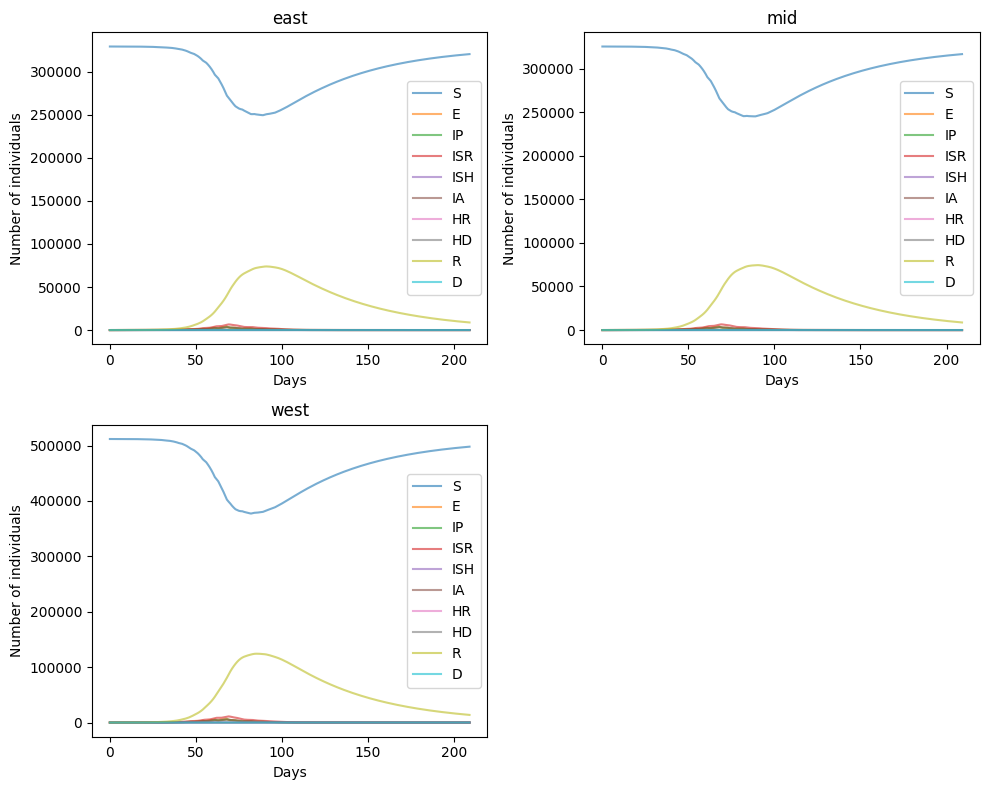

In [8]:
# Generate simple compartment history plot for flu model
clt.plot_metapop_basic_compartment_history(flu_demo_model)

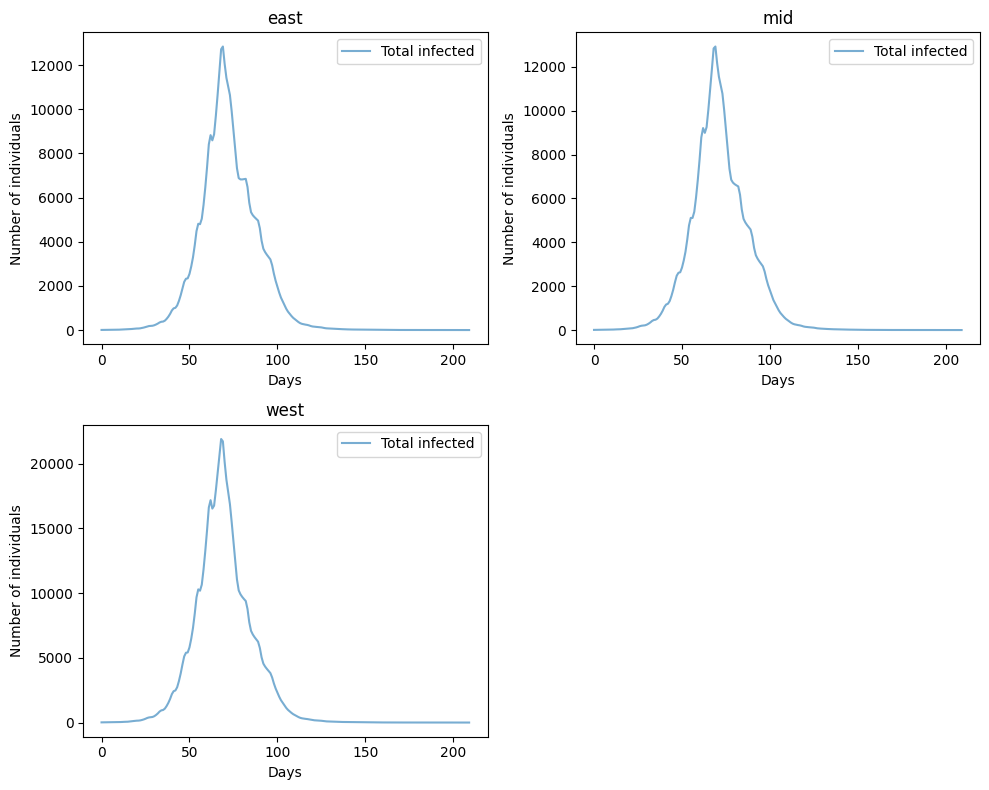

In [9]:
clt.plot_metapop_total_infected(flu_demo_model)


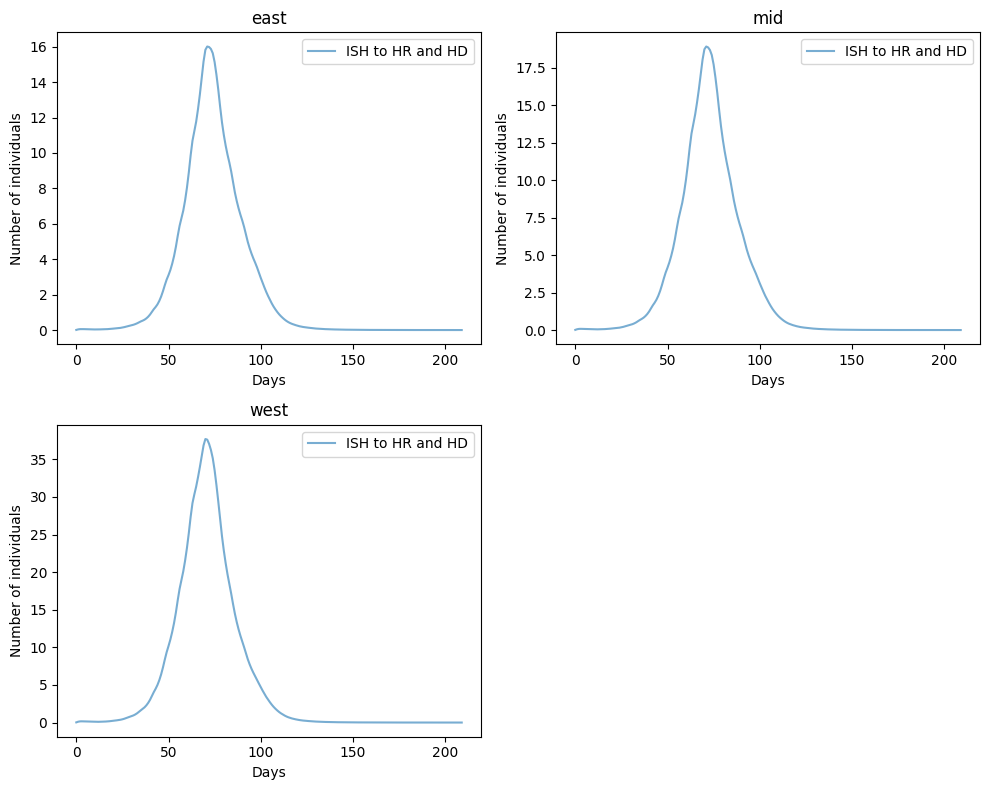

In [10]:
clt.plot_metapop_TransitionVariable(flu_demo_model)

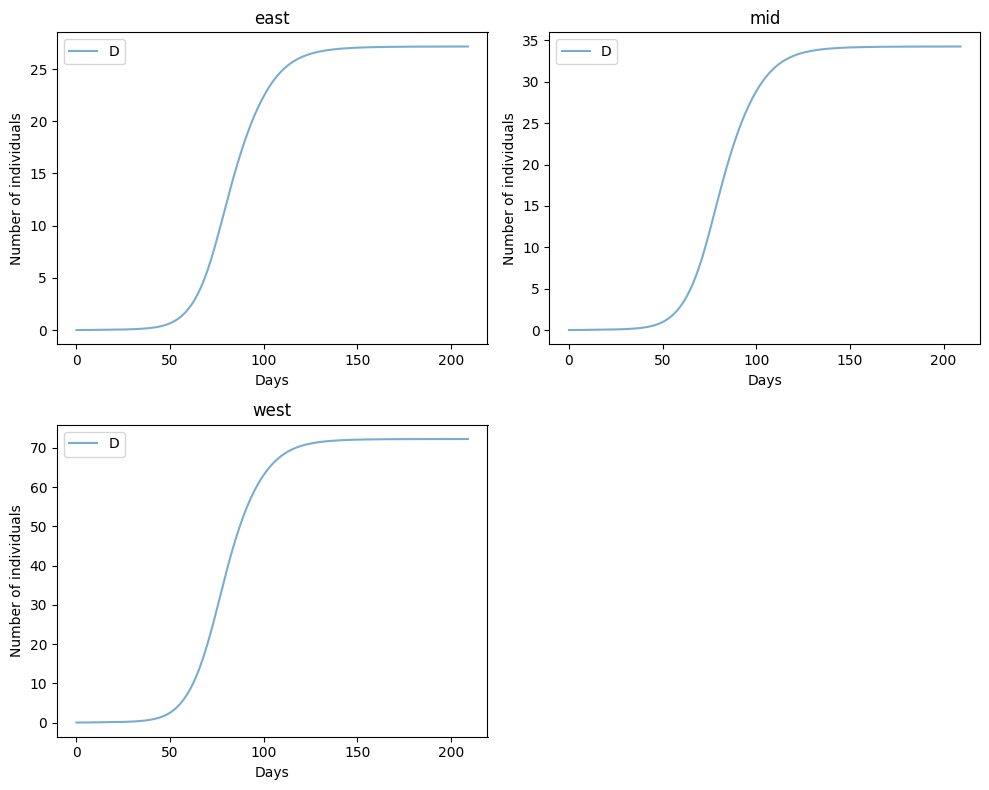

In [11]:
clt.plot_metapop_total_deaths(flu_demo_model)

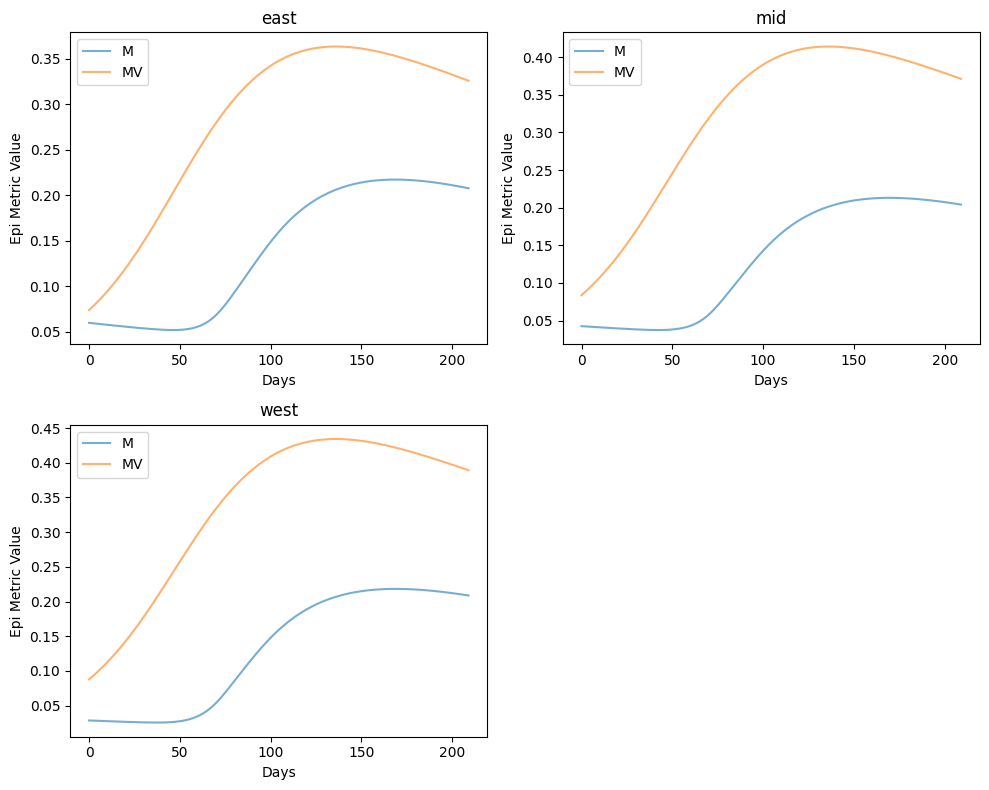

In [12]:
clt.plot_metapop_epi_metrics(flu_demo_model)

In [13]:
# Print the %population exposed 
# knowing that some individuals are exposed twice since have R to S, many protected by immunity, but possibly not all
print(round(np.sum(np.asarray(east.transition_variables.S_to_E.history_vals_list))/NumIndiv_east,3))
print(round(np.sum(np.asarray(mid.transition_variables.S_to_E.history_vals_list))/NumIndiv_mid,3))
print(round(np.sum(np.asarray(west.transition_variables.S_to_E.history_vals_list))/NumIndiv_west,3))

0.386
0.393
0.413


In [14]:
# Print the per capita number of hospitalizations for east and west Austin
east_IS_to_H = np.asarray(east.transition_variables.ISH_to_HR.history_vals_list) + \
    np.asarray(east.transition_variables.ISH_to_HD.history_vals_list)
mid_IS_to_H = np.asarray(mid.transition_variables.ISH_to_HR.history_vals_list) + \
    np.asarray(mid.transition_variables.ISH_to_HD.history_vals_list)
west_IS_to_H = np.asarray(west.transition_variables.ISH_to_HR.history_vals_list) + \
    np.asarray(west.transition_variables.ISH_to_HD.history_vals_list)
eastHosp = round(np.sum(east_IS_to_H)/NumIndiv_east*100000)
midHosp = round(np.sum(mid_IS_to_H)/NumIndiv_mid*100000)
westHosp = round(np.sum(west_IS_to_H)/NumIndiv_west*100000)
print(eastHosp)
print(midHosp)
print(westHosp)

151
180
226


In [15]:
# Timing of hospitalization peak, first for East
# First need to sum over all "H" compartments
hospit_compartment_names = [name for name in east.compartments.keys() if "H" in name]
hospit_compartments_history = [east.compartments[compartment_name].history_vals_list for compartment_name in hospit_compartment_names]
total_hospitE = np.sum(np.asarray(hospit_compartments_history), axis=(0, 2, 3))
print(np.argmax(total_hospitE))

# then for Mid
hospit_compartment_names = [name for name in mid.compartments.keys() if "H" in name]
hospit_compartments_history = [mid.compartments[compartment_name].history_vals_list for compartment_name in hospit_compartment_names]
total_hospitM = np.sum(np.asarray(hospit_compartments_history), axis=(0, 2, 3))
print(np.argmax(total_hospitM))

# then for West
hospit_compartment_names = [name for name in west.compartments.keys() if "H" in name]
hospit_compartments_history = [west.compartments[compartment_name].history_vals_list for compartment_name in hospit_compartment_names]
total_hospitW = np.sum(np.asarray(hospit_compartments_history), axis=(0, 2, 3))
print(np.argmax(total_hospitW))

74
73
72


In [16]:
## Total number of deaths is the number at the end (so last element in the array [-1]), since no one leaves death compartment
## Then sum across all age groups
Deaths = np.sum(np.asarray(east.compartments.D.history_vals_list)[-1])/NumIndiv_east*100000
print(round(Deaths,0))
Deaths = np.sum(np.asarray(mid.compartments.D.history_vals_list)[-1])/NumIndiv_mid*100000
print(round(Deaths,0))
Deaths = np.sum(np.asarray(west.compartments.D.history_vals_list)[-1])/NumIndiv_west*100000
print(round(Deaths,0))

8.0
11.0
14.0
